In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt 
from ultralytics import YOLO
import time
import shutil

TASK 2

Total No of Blurred Images :  1029
Total No of sharp Images :  1029
Blur Image Shape : (720, 1280, 3)
Sharp image Shape :  (720, 1280, 3)


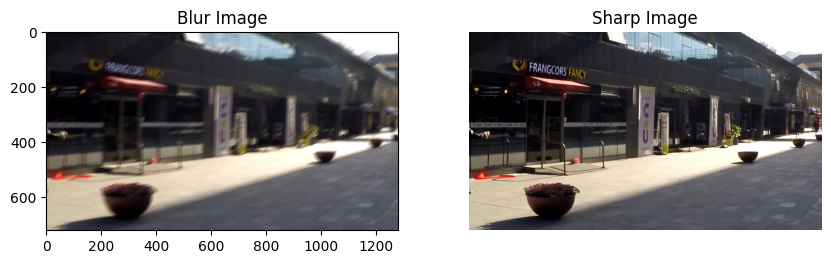

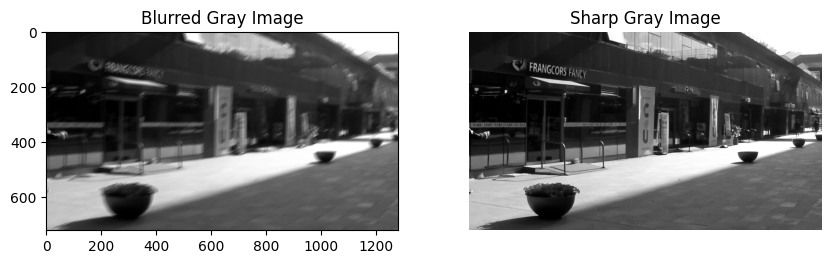

Blur Kernel  Shape : (25, 25)


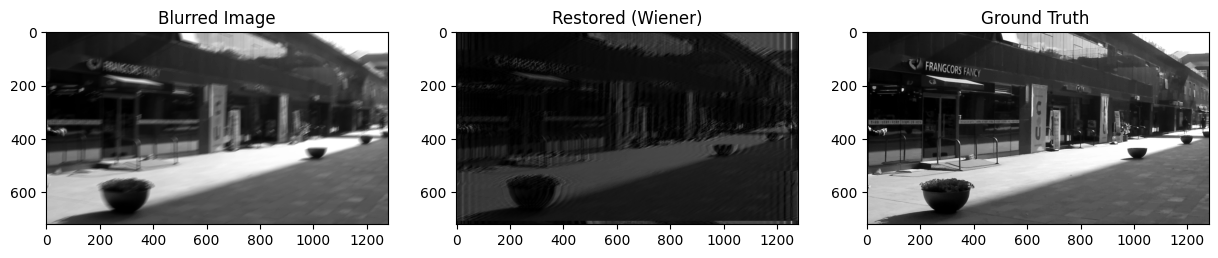

PSNR :  9.50953612209963 db


In [2]:
# Uploading the Dataset
blur_path ="dataset/gopro_deblur/blur/images"
sharp_path = "dataset/gopro_deblur/sharp/images"
# listing the images 
blur_images = sorted(os.listdir(blur_path))
sharp_images = sorted(os.listdir(sharp_path))

print("Total No of Blurred Images : ",len(blur_images))
print("Total No of sharp Images : ",len(sharp_images))


# Loading the one blurred and one sharp image
blur_image=cv2.imread(os.path.join(blur_path,blur_images[0]))
sharp_image = cv2.imread(os.path.join(sharp_path,sharp_images[0]))
#The images are in BGR fromat wer are converting them to RGB fromat
blur_image =cv2.cvtColor(blur_image,cv2.COLOR_BGR2RGB)
sharp_image = cv2.cvtColor(sharp_image,cv2.COLOR_BGR2RGB)

print("Blur Image Shape :",blur_image.shape)
print("Sharp image Shape : ",sharp_image.shape)

#Displaying the images 
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(blur_image)
plt.title("Blur Image")

plt.subplot(1,2,2)
plt.imshow(sharp_image)
plt.title("Sharp Image")
plt.axis("off")
plt.show()

#Converting the images to grayscale
blur_gray = cv2.cvtColor(blur_image,cv2.COLOR_RGB2GRAY)
sharp_gray =cv2.cvtColor(sharp_image,cv2.COLOR_RGB2GRAY)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(blur_gray,cmap="gray")
plt.title("Blurred Gray Image")

#creating a plot for sharp gray image 
plt.subplot(1,2,2)
plt.imshow(sharp_gray,cmap="gray")
plt.title("Sharp Gray Image")
plt.axis("off")
plt.show()

#Normalizing the images 
blur_gray = blur_gray.astype(np.float64) / 255.0
sharp_gray = sharp_gray.astype(np.float64) / 255.0

#creating Motion Blur Kernel
kernel_size = 25
kernel =np.zeros((kernel_size, kernel_size))
kernel[int((kernel_size-1)/2), :] = np.ones(kernel_size)
kernel =kernel / kernel_size
print("Blur Kernel  Shape :",kernel.shape)

#Now we are Applying Wiener Deblurring
def wiener_filter(img,kernel,K=0.01):
    # Compute the Fourier Transform of the image and kernel
    img_fft = np.fft.fft2(img)
    kernel_fft = np.fft.fft2(kernel, s=img.shape)
    
    # Compute the Wiener filter
    kernel_conj = np.conj(kernel_fft)

    result_fft =(kernel_conj/(np.abs(kernel_fft)**2 +K))*img_fft
    result =np.abs(np.fft.ifft2(result_fft))
    #Normalize result 
    result = (result - result.min()) / (result.max() - result.min())

    return result
restored = wiener_filter(blur_gray, kernel,K=0.01)

#Comparing the results 

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(blur_gray,cmap="gray")
plt.title("Blurred Image")

plt.subplot(1,3,2)
plt.imshow(restored,cmap="gray")
plt.title("Restored (Wiener)")

plt.subplot(1,3,3)
plt.imshow(sharp_gray,cmap="gray")
plt.title("Ground Truth ")
plt.show()

def compute_psnr(original, restored):
    mse = np.mean((original -restored)**2)
    if mse ==0:
        return float('inf')
    max_pixel =1.0
    psnr =20*np.log10(max_pixel / np.sqrt(mse))
    return psnr 
psnr_value = compute_psnr(sharp_gray,restored)
print("PSNR : ",psnr_value,"db")

TASK 3


0: 384x640 (no detections), 193.4ms
Speed: 7.5ms preprocess, 193.4ms inference, 5.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 281.8ms
Speed: 4.6ms preprocess, 281.8ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)
Objects Detected in Blurred Image :  0
Objects Detected in Restored Image :  0

0: 384x640 (no detections), 88.2ms
Speed: 2.7ms preprocess, 88.2ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)
Blur detection runtime :  0.31220221519470215 seconds
Restored detection runtime :  0.09530401229858398 seconds

0: 384x640 (no detections), 119.2ms
Speed: 2.9ms preprocess, 119.2ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)
Image 1 detections: 0

0: 384x640 1 bowl, 1 potted plant, 89.7ms
Speed: 3.5ms preprocess, 89.7ms inference, 5.2ms postprocess per image at shape (1, 3, 384, 640)
Image 2 detections: 2

0: 384x640 2 bowls, 84.9ms
Speed: 2.7ms preprocess, 84.9ms inference, 1.1ms postproces

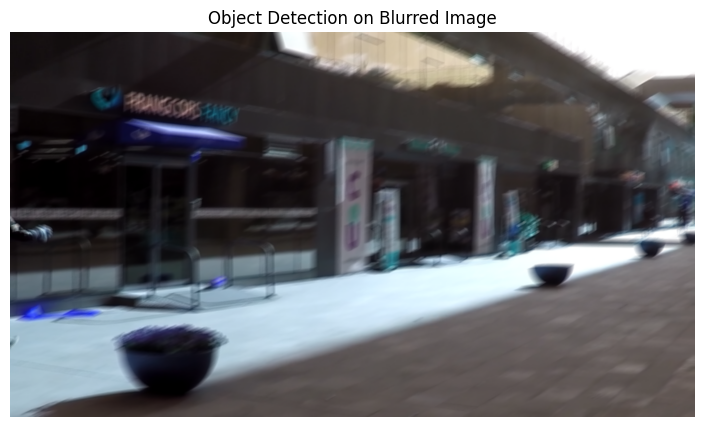

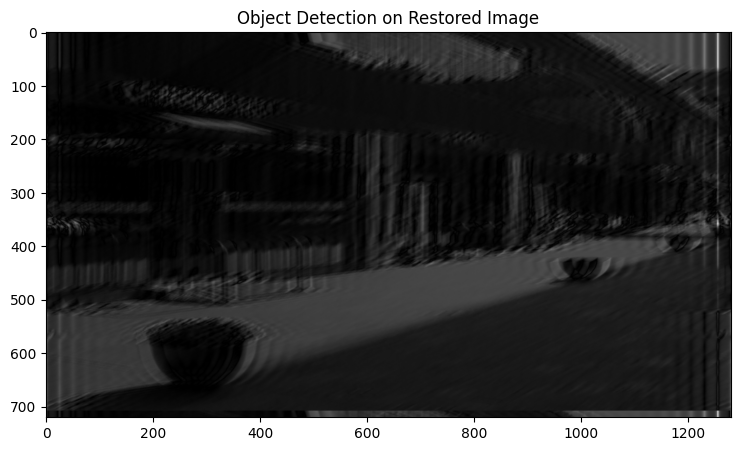

In [3]:
model = YOLO("yolov8n.pt")

#Converting RGB image to BGR 
blur_bgr = cv2.cvtColor(blur_image,cv2.COLOR_RGB2BGR)
#Runnig Object Detection 
start_time = time.time()
blur_results = model(blur_bgr)
blur_runtime = time.time() - start_time
#plot detection results
blur_detected = blur_results[0].plot()
plt.figure(figsize=(10,5))
plt.imshow(blur_detected)
plt.title("Object Detection on Blurred Image")
plt.axis("off")
#Converting the restored image to uint8
restored_uint8 = (restored *255).astype(np.uint8)
#Convert grayscale to RGB
restored_rgb = cv2.cvtColor(restored_uint8,cv2.COLOR_GRAY2RGB)
#Converting RGB to BGR
restored_bgr =cv2.cvtColor(restored_rgb,cv2.COLOR_RGB2BGR)
#Run Detection 
restored_results =model(restored_bgr)
#PLot results 
restored_detected  = restored_results[0].plot()

plt.figure(figsize=(10,5))
plt.imshow(cv2.cvtColor(restored_detected,cv2.COLOR_BGR2RGB))
plt.title("Object Detection on Restored Image")
# compare number of detections 
blur_count = len(blur_results[0].boxes)
restored_count = len(restored_results[0].boxes)
print("Objects Detected in Blurred Image : ",blur_count)
print("Objects Detected in Restored Image : ",restored_count)
start_time = time.time()
restored_results = model(restored_bgr)
restored_runtime = time.time() - start_time
print("Blur detection runtime : ", blur_runtime,"seconds")
print("Restored detection runtime : ",restored_runtime,"seconds")

for i in range(5):
    
    blur_image = cv2.imread(os.path.join(blur_path, blur_images[i]))
    blur_image = cv2.cvtColor(blur_image, cv2.COLOR_BGR2RGB)

    blur_bgr = cv2.cvtColor(blur_image, cv2.COLOR_RGB2BGR)

    results = model(blur_bgr)

    print("Image", i+1, "detections:", len(results[0].boxes))


TASK 4

In [21]:
subset_size = 50

train_blur_dir = "dataset/train/blur"
train_sharp_dir = "dataset/train/sharp"
deblur_dir = "dataset/train/deblur"
os.makedirs(train_blur_dir, exist_ok=True)
os.makedirs(train_sharp_dir, exist_ok=True)
os.makedirs(deblur_dir, exist_ok=True)

for i in range(subset_size):

    shutil.copy(
        os.path.join(blur_path, blur_images[i]),
        os.path.join(train_blur_dir, blur_images[i])
    )

    shutil.copy(
        os.path.join(sharp_path, sharp_images[i]),
        os.path.join(train_sharp_dir, sharp_images[i])
    )
blur_images_train = sorted(os.listdir(train_blur_dir))
for img_name in blur_images_train:
    img_path = os.path.join(train_blur_dir, img_name)
    blur_image = cv2.imread(img_path)
    blur_gray = cv2.cvtColor(blur_image, cv2.COLOR_BGR2GRAY)
    blur_gray = blur_gray.astype(np.float64) / 255.0
    restored = wiener_filter(blur_gray, kernel)
    restored_uint8 = (restored * 255).astype("uint8")
    save_path = os.path.join(deblur_dir, img_name)
    cv2.imwrite(save_path, restored_uint8)

model = YOLO("yolov8n.pt")
model.train(
    data="dataset/dataset.yaml",
    epochs=10,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.21  Python-3.13.1 torch-2.8.0+cpu CPU (Intel Core i5-10300H 2.50GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train12, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, 

c:\Users\Niyaz Ahmed Shayan\AppData\Local\Programs\Python\Python313\Lib\site-packages\ultralytics\utils\metrics.py:839: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
C:\Users\Niyaz Ahmed Shayan\AppData\Roaming\Python\Python313\site-packages\numpy\_core\_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/10         0G          0      117.9          0          0        640: 50% ━━━━━━────── 2/4 1.8it/s 13.2s<1.1s8


KeyboardInterrupt: 

In [20]:
import os

print("Blur images:", len(os.listdir("dataset/train/blur")))

Blur images: 50
